In [18]:
import pandas as pd
df = pd.read_csv('Reviews.csv', nrows=5000)

In [19]:
print(" First 10 Rows of the Dataset ")
display(df.head(10))

 First 10 Rows of the Dataset 


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [20]:
print(" Number of rows and columns")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

 Number of rows and columns
Rows: 5000
Columns: 10


In [21]:
print(df.columns.tolist())

['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']


In [22]:
# 1. Remove rows where review text is empty or null
df.dropna(subset=['Text'], inplace=True)

In [23]:
# 2. Remove duplicate reviews
df.drop_duplicates(subset=['Text'], inplace=True)

In [24]:
# 3. Keep only the columns you need: review text + rating (score)
df = df[['Text', 'Score']]

In [25]:
# Displaying the cleaned dataframe
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 4984 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Text    4984 non-null   object
 1   Score   4984 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 116.8+ KB
None


In [26]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [27]:

from textblob import TextBlob

# 1. Function to calculate the polarity score for each review text 
def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

# 2. Function to label the sentiment
def get_sentiment(score):
    if score > 0:
        return 'Positive'  
    elif score < 0:
        return 'Negative'   
    else:
        return 'Neutral'    

# 3. Applying these functions to DataFrame
df['Polarity_Score'] = df['Text'].apply(get_polarity)
df['Sentiment_Label'] = df['Polarity_Score'].apply(get_sentiment)

# 4. result
df[['Text', 'Polarity_Score', 'Sentiment_Label']].head(10)

,Text,Polarity_Score,Sentiment_Label
0,I have bought several of the Vitality canned d...,0.450000,Positive
1,Product arrived labeled as Jumbo Salted Peanut...,-0.033333,Negative
2,This is a confection that has been around a fe...,0.133571,Positive
3,If you are looking for the secret ingredient i...,0.166667,Positive
4,Great taffy at a great price. There was a wid...,0.483333,Positive
5,I got a wild hair for taffy and ordered this f...,0.257407,Positive
6,This saltwater taffy had great flavors and was...,0.250833,Positive
7,This taffy is so good. It is very soft and ch...,0.486000,Positive
8,Right now I'm mostly just sprouting this so my...,0.428571,Positive
9,This is a very healthy dog food. Good for thei...,0.450000,Positive


In [28]:
# Display the 10 most negative reviews to see what they are complaining about
print(df[df['Sentiment_Label'] == 'Negative']['Text'].head(10).values)

['Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".'
 'The Strawberry Twizzlers are my guilty pleasure - yummy. Six pounds will be around for a while with my son and I.'
 "This oatmeal is not good. Its mushy, soft, I don't like it. Quaker Oats is the way to go."
 "This wasn't in stock the last time I looked. I had to go to the Vermont Country Store in Weston to find it along with a jaw harp, Cranberry Horseradish Sauce, Fartless Black Bean Salsa, Apple Cider Jelly, Newton's Cradle Art in Motion and the staple Vermont Maple Syrup.<br /><br />Back to the Ass Kickin Peanuts. They are hot. They will activate the perspiration glands behind your ears and under your arms. It requires a beverage as advertised, a glass of very cold milk, and a box of Kleenex since it will make your nose run. They look like ordinary peanuts which is already giving me ideas 

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

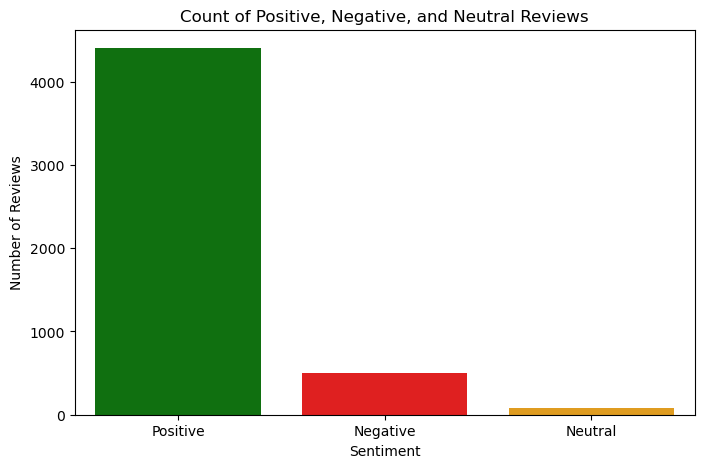

In [30]:
# Chart 1: Bar Chart
custom_colors = {
    'Positive': 'green',
    'Negative': 'red',
    'Neutral': 'orange'
}
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Sentiment_Label', 
    data=df, 
    palette=custom_colors, 
    hue='Sentiment_Label', 
    legend=False
)
plt.title('Count of Positive, Negative, and Neutral Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.savefig('bar_chart.png')
plt.show()

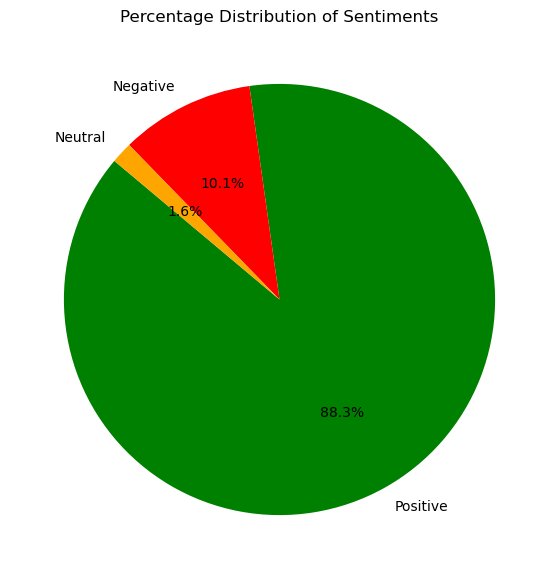

In [31]:
# Chart 2: Pie Chart
plt.figure(figsize=(7, 7))
sentiment_counts = df['Sentiment_Label'].value_counts()
pie_colors = [custom_colors[label] for label in sentiment_counts.index]

plt.pie(
    sentiment_counts, 
    labels=sentiment_counts.index, 
    autopct='%1.1f%%', 
    colors=pie_colors,
    startangle=140
)
plt.title('Percentage Distribution of Sentiments')
plt.savefig('pie_chart.png')
plt.show()

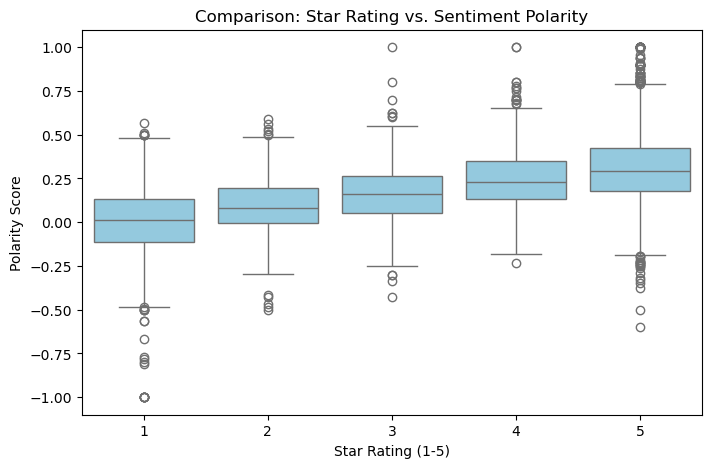

In [32]:
# Chart 3: Box Plot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Score', y='Polarity_Score', data=df, color='skyblue')
plt.title('Comparison: Star Rating vs. Sentiment Polarity')
plt.xlabel('Star Rating (1-5)')
plt.ylabel('Polarity Score')
plt.savefig('custom_chart.png')
plt.show()

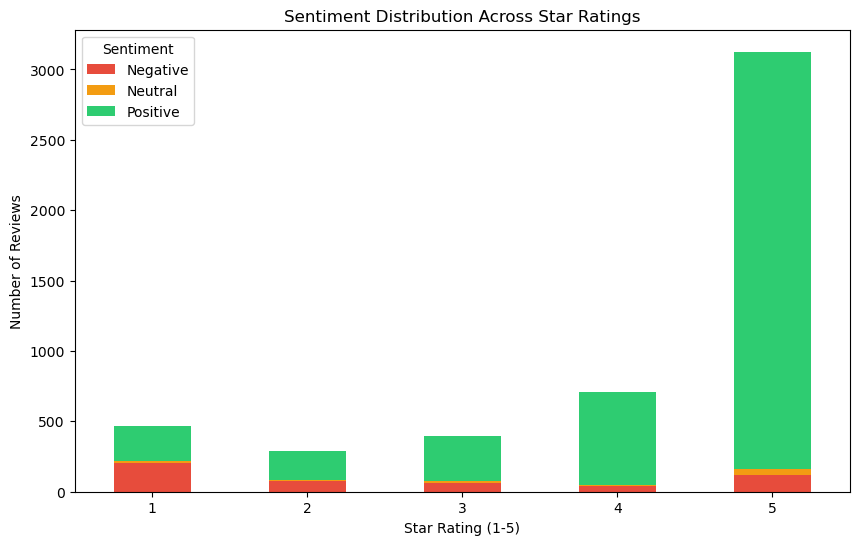

In [34]:
# Chart 4: Sentiment Distribution by Star Rating chart [Bar Chart]
plt.figure(figsize=(10, 6))
sentiment_by_rating = pd.crosstab(df['Score'], df['Sentiment_Label'])

# Plotting a stacked bar chart
sentiment_by_rating.plot(kind='bar', 
                         stacked=True, 
                         color=[hex_colors['Negative'], hex_colors['Neutral'], hex_colors['Positive']],
                         ax=plt.gca())

plt.title('Sentiment Distribution Across Star Ratings')
plt.xlabel('Star Rating (1-5)')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.xticks(rotation=0)
plt.savefig('custom_chart_2.png')
plt.show()

Based on the sentiment analysis of 5,000 Amazon Fine Food reviews, most of the customers provided positive feedback, which indicates high overall satisfaction with the products. By inspecting the negative reviews, it appears that customers mostly complain about damaged packaging or the taste failed to meet expectations. One surprising finding in the data was that some 5-star ratings actually contained negative text or vice versa, suggesting that star ratings don't always tell the full story. My primary recommendation for the business is to focus on improving the quality control of packaging to reduce negative sentiment.